# Hybrid Movie Recommendation System (TMDB 5000 Dataset)

**Dataset:** [TMDB 5000 Movie Dataset](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata) (Kaggle)
- `tmdb_5000_movies.csv` - budget, genres, keywords, overview, popularity, ratings, etc.
- `tmdb_5000_credits.csv` - cast and crew for each movie

**Approach:** Hybrid recommendation combining:
1. **Content-based filtering** - TF-IDF + cosine similarity over each movie's genres, overview,
   top cast, director, and keywords.
2. **Weighted rating (IMDB-style Bayesian average)** - re-ranks the content-similar candidates by
   a rating that accounts for vote count, so a movie with 5 votes at 9.0 doesn't outrank one with
   5,000 votes at 8.4.

The two signals are blended into a single `hybrid_score` used to produce the final recommendation list.


## 1. Load the data

In [1]:
import pandas as pd
import numpy as np
import ast

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

print(f"movies: {movies.shape}, credits: {credits.shape}")
movies.head(3)

movies: (4803, 20), credits: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [2]:
credits.head(3)

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## 2. First inspection

In [3]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status                4803 non-n

In [4]:
movies.isna().sum()

budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

## 3. Merge movies and credits

Both files share the movie id (`id` in `movies`, `movie_id` in `credits`), so merge on that.

In [5]:
credits = credits.rename(columns={'movie_id': 'id'})
df = movies.merge(credits[['id', 'cast', 'crew']], on='id')
print(df.shape)
df[['title', 'genres', 'cast', 'crew']].head(3)

(4803, 22)


,title,genres,cast,crew
0,Avatar,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,Pirates of the Caribbean: At World's End,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,Spectre,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## 4. Handle missing values

- `homepage` and `tagline` are missing for a large share of movies - not usable as recommendation
  features anyway, dropped from the working set.
- `overview` missing for a handful of movies - these can't be used for content-based similarity
  (no text to compare), so they're dropped.
- `release_date` missing for 1 row - dropped, negligible loss.
- `runtime` missing for a couple of rows - filled with the median runtime rather than dropped,
  since runtime isn't used in the similarity calculation, no need to lose the row over it.

In [6]:
print("Missing before cleaning:")
print(df[['overview', 'release_date', 'runtime', 'tagline', 'homepage']].isna().sum())

df = df.drop(columns=['homepage', 'tagline'])
df = df.dropna(subset=['overview', 'release_date']).reset_index(drop=True)
df['runtime'] = df['runtime'].fillna(df['runtime'].median())

print("\nMissing after cleaning:")
print(df.isna().sum().sum(), "total remaining nulls")
print(df.shape)

Missing before cleaning:
overview           3
release_date       1
runtime            2
tagline          844
homepage        3091
dtype: int64

Missing after cleaning:
0 total remaining nulls
(4799, 20)


## 5. Parse the nested JSON-like columns

`genres`, `keywords`, `cast`, and `crew` are stored as stringified lists of dicts (a common TMDB
export quirk). Parse them with `ast.literal_eval` and pull out just the fields we need:
genre names, keyword names, top 5 cast members, and the director's name.

In [7]:
def parse_names(text, limit=None):
    try:
        items = ast.literal_eval(text)
    except (ValueError, SyntaxError):
        return []
    names = [item['name'] for item in items]
    return names[:limit] if limit else names

def get_director(crew_text):
    try:
        crew = ast.literal_eval(crew_text)
    except (ValueError, SyntaxError):
        return ''
    for member in crew:
        if member.get('job') == 'Director':
            return member['name']
    return ''

df['genres_list'] = df['genres'].apply(parse_names)
df['keywords_list'] = df['keywords'].apply(parse_names)
df['cast_list'] = df['cast'].apply(lambda x: parse_names(x, limit=5))
df['director'] = df['crew'].apply(get_director)
df['director'] = df['director'].replace('', 'Unknown')

df[['title', 'genres_list', 'cast_list', 'director']].head(3)

,title,genres_list,cast_list,director
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[Sam Worthington, Zoe Saldana, Sigourney Weave...",James Cameron
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[Johnny Depp, Orlando Bloom, Keira Knightley, ...",Gore Verbinski
2,Spectre,"[Action, Adventure, Crime]","[Daniel Craig, Christoph Waltz, Léa Seydoux, R...",Sam Mendes


## 6. Feature engineering

Combine genres, overview, cast, director, and keywords into one "tags" field per movie -
this is what TF-IDF will vectorize for content-based similarity. Names are squashed to single
tokens (e.g. "Science Fiction" -> "sciencefiction") so multi-word names aren't split apart by
the vectorizer.

In [8]:
def squash(names):
    return [n.replace(' ', '').lower() for n in names]

df['tags'] = (
    df['genres_list'].apply(squash).apply(' '.join) + ' ' +
    df['overview'].fillna('').str.lower() + ' ' +
    df['cast_list'].apply(squash).apply(' '.join) + ' ' +
    df['director'].apply(lambda x: x.replace(' ', '').lower()) + ' ' +
    df['keywords_list'].apply(squash).apply(' '.join)
)

df[['title', 'tags']].head(3)

,title,tags
0,Avatar,action adventure fantasy sciencefiction in the...
1,Pirates of the Caribbean: At World's End,"adventure fantasy action captain barbossa, lon..."
2,Spectre,action adventure crime a cryptic message from ...


## 7. Content-based filtering (TF-IDF + cosine similarity)

In [9]:
tfidf = TfidfVectorizer(stop_words='english', max_features=8000)
tfidf_matrix = tfidf.fit_transform(df['tags'])

similarity = cosine_similarity(tfidf_matrix)
print(f"Similarity matrix shape: {similarity.shape}")

Similarity matrix shape: (4799, 4799)


## 8. Weighted rating (IMDB-style Bayesian average)

Standard formula: `WR = (v / (v + m)) * R + (m / (v + m)) * C`

- `R` = movie's average rating
- `v` = movie's vote count
- `m` = minimum votes required to be considered (70th percentile of vote counts)
- `C` = mean rating across the whole dataset

In [10]:
C = df['vote_average'].mean()
m = df['vote_count'].quantile(0.70)
print(f"C (mean rating) = {C:.3f}, m (min votes threshold) = {m:.0f}")

def weighted_rating(row, m=m, C=C):
    v = row['vote_count']
    R = row['vote_average']
    return (v / (v + m)) * R + (m / (v + m)) * C

df['weighted_rating'] = df.apply(weighted_rating, axis=1)
df[['title', 'vote_average', 'vote_count', 'weighted_rating']].sort_values('weighted_rating', ascending=False).head(10)

C (mean rating) = 6.094, m (min votes threshold) = 581


,title,vote_average,vote_count,weighted_rating
1881,The Shawshank Redemption,8.5,8205,8.340909
3336,The Godfather,8.4,5893,8.193068
662,Fight Club,8.3,9413,8.171765
3231,Pulp Fiction,8.3,8428,8.157745
65,The Dark Knight,8.2,12002,8.102767
809,Forrest Gump,8.2,7927,8.056197
1818,Schindler's List,8.3,4329,8.038986
3864,Whiplash,8.3,4254,8.034937
96,Inception,8.1,13752,8.018693
1990,The Empire Strikes Back,8.2,5879,8.010607


## 9. Hybrid recommender function

For a given movie:
1. Find the most content-similar movies (TF-IDF cosine similarity)
2. Re-rank that shortlist by a blend of similarity score and weighted rating
   (so among similar movies, the better-reviewed ones surface first)

In [11]:
indices = pd.Series(df.index, index=df['title'].str.lower())

def recommend(title, top_n=10, similarity_weight=0.6):
    title_lower = title.lower()
    if title_lower not in indices:
        matches = df[df['title'].str.lower().str.contains(title_lower, na=False)]
        if matches.empty:
            print(f"'{title}' not found in the dataset. Try a different title.")
            return None
        idx = matches.index[0]
        print(f"Exact match not found, using closest match: '{df.loc[idx, 'title']}'")
    else:
        idx = indices[title_lower]
        if isinstance(idx, pd.Series):
            idx = idx.iloc[0]

    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = [s for s in sim_scores if s[0] != idx]
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[:30]

    candidates = df.iloc[[s[0] for s in sim_scores]].copy()
    candidates['similarity'] = [s[1] for s in sim_scores]

    wr_min, wr_max = candidates['weighted_rating'].min(), candidates['weighted_rating'].max()
    candidates['wr_norm'] = 0 if wr_max == wr_min else (candidates['weighted_rating'] - wr_min) / (wr_max - wr_min)

    candidates['hybrid_score'] = (
        similarity_weight * candidates['similarity'] +
        (1 - similarity_weight) * candidates['wr_norm']
    )

    result = candidates.sort_values('hybrid_score', ascending=False).head(top_n)
    return result[['title', 'vote_average', 'vote_count', 'similarity', 'hybrid_score']].reset_index(drop=True)

recommend('The Dark Knight', top_n=10)

,title,vote_average,vote_count,similarity,hybrid_score
0,The Dark Knight Rises,7.6,9106,0.448347,0.633642
1,Batman Begins,7.5,7359,0.342090,0.555013
2,"Batman: The Dark Knight Returns, Part 2",7.9,419,0.319999,0.469561
3,The Prestige,8.0,4391,0.075516,0.445310
4,Batman Returns,6.6,1673,0.361711,0.444211
5,Inglourious Basterds,7.9,6430,0.070233,0.438579
6,Batman,7.0,2096,0.253055,0.423129
7,The Lego Movie,7.5,3070,0.118214,0.404717
8,Children of Men,7.4,2071,0.072702,0.355953
9,The Wizard of Oz,7.4,1642,0.070963,0.347614


In [12]:
recommend('Inception', top_n=10)

,title,vote_average,vote_count,similarity,hybrid_score
0,The Revenant,7.3,6396,0.087189,0.452314
1,(500) Days of Summer,7.2,2904,0.097387,0.408941
2,Mission: Impossible - Rogue Nation,7.1,3224,0.096859,0.389999
3,Kiss Kiss Bang Bang,7.2,886,0.084530,0.332995
4,50/50,7.0,1261,0.087631,0.322006
5,Pitch Perfect 2,6.8,1940,0.107834,0.313423
6,The Walk,6.9,1121,0.097826,0.304079
7,Looper,6.6,4697,0.100107,0.283761
8,Layer Cake,7.0,559,0.080974,0.270675
9,Mean Streets,7.2,345,0.078257,0.260389


In [13]:
recommend('The Avengers', top_n=10)

,title,vote_average,vote_count,similarity,hybrid_score
0,Avengers: Age of Ultron,7.3,6767,0.407962,0.567018
1,Captain America: The Winter Soldier,7.6,5764,0.219243,0.487506
2,Guardians of the Galaxy,7.9,9742,0.136196,0.481718
3,Iron Man,7.4,8776,0.183236,0.447147
4,Captain America: Civil War,7.1,7241,0.242983,0.444538
5,Ant-Man,7.0,5880,0.163570,0.382910
6,Iron Man 3,6.8,8806,0.186375,0.375345
7,Thor: The Dark World,6.8,4755,0.186804,0.371258
8,X-Men: First Class,7.1,5181,0.115571,0.364593
9,Iron Man 2,6.6,6849,0.195780,0.355335


## 10. Visualizations

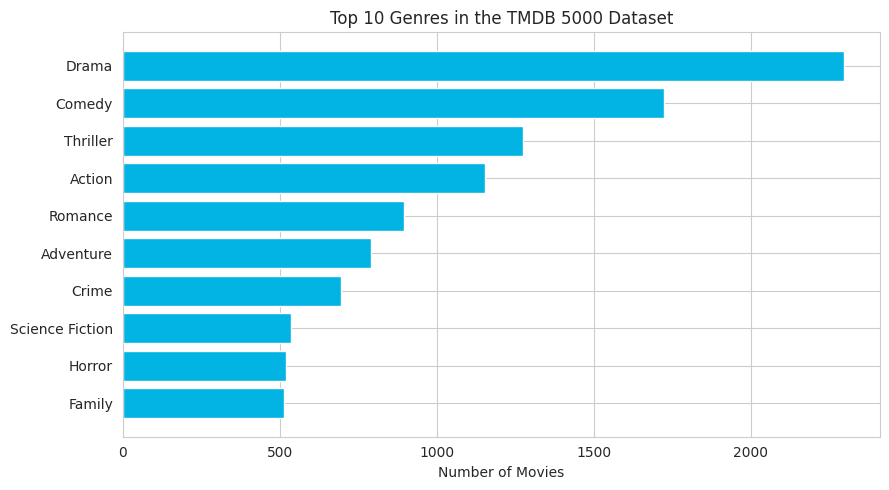

In [14]:
top_genres = df['genres_list'].explode().value_counts().head(10)
plt.figure(figsize=(9,5))
plt.barh(top_genres.index[::-1], top_genres.values[::-1], color='#01b4e4')
plt.title('Top 10 Genres in the TMDB 5000 Dataset')
plt.xlabel('Number of Movies')
plt.tight_layout()
plt.savefig('viz_top_genres.png', dpi=120)
plt.show()

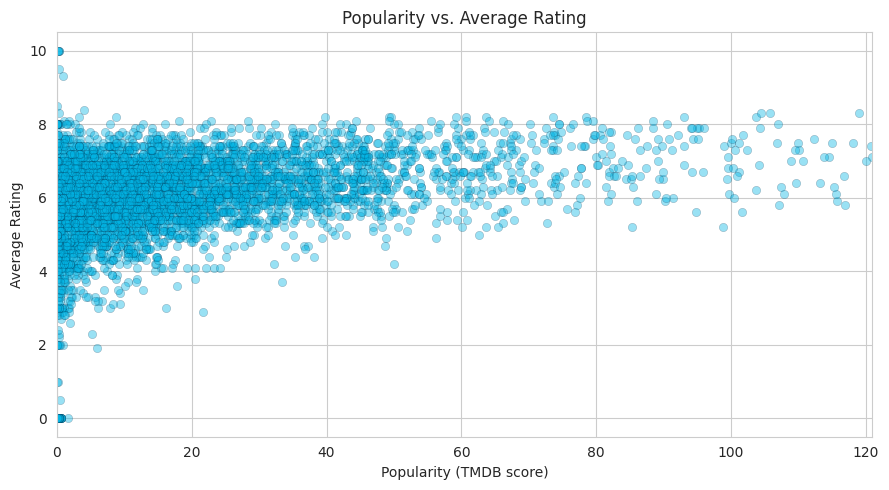

In [15]:
plt.figure(figsize=(9,5))
plt.scatter(df['popularity'], df['vote_average'], alpha=0.4, c='#01b4e4', edgecolors='#032541', linewidths=0.3)
plt.title('Popularity vs. Average Rating')
plt.xlabel('Popularity (TMDB score)')
plt.ylabel('Average Rating')
plt.xlim(0, df['popularity'].quantile(0.99))
plt.tight_layout()
plt.savefig('viz_popularity_vs_rating.png', dpi=120)
plt.show()

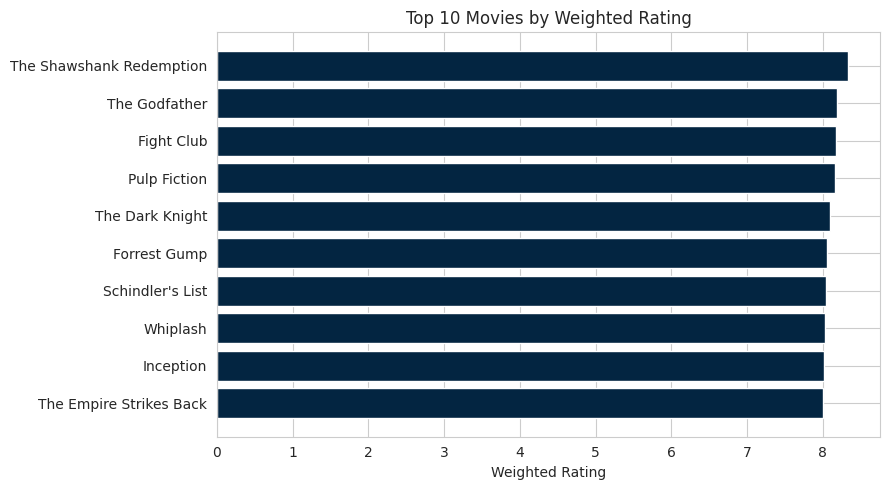

In [16]:
top_rated = df.sort_values('weighted_rating', ascending=False).head(10)
plt.figure(figsize=(9,5))
plt.barh(top_rated['title'][::-1], top_rated['weighted_rating'][::-1], color='#032541')
plt.title('Top 10 Movies by Weighted Rating')
plt.xlabel('Weighted Rating')
plt.tight_layout()
plt.savefig('viz_top_rated.png', dpi=120)
plt.show()

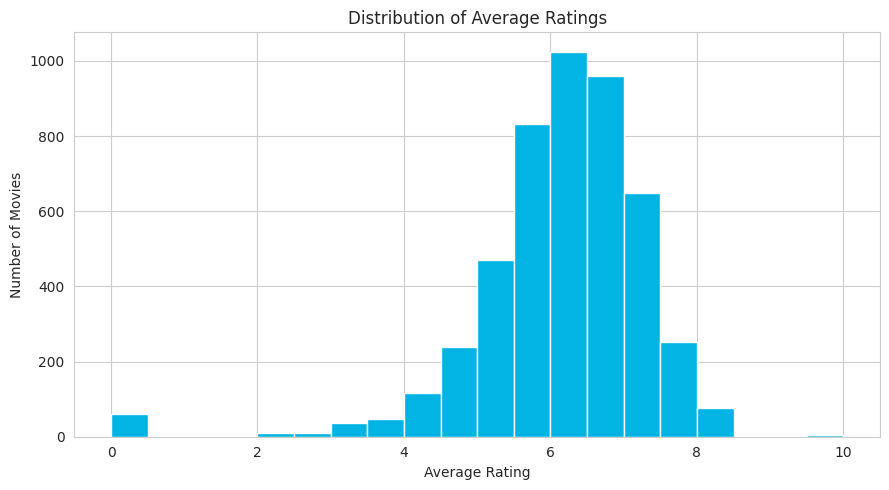

In [17]:
plt.figure(figsize=(9,5))
plt.hist(df['vote_average'], bins=20, color='#01b4e4', edgecolor='white')
plt.title('Distribution of Average Ratings')
plt.xlabel('Average Rating')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('viz_rating_distribution.png', dpi=120)
plt.show()

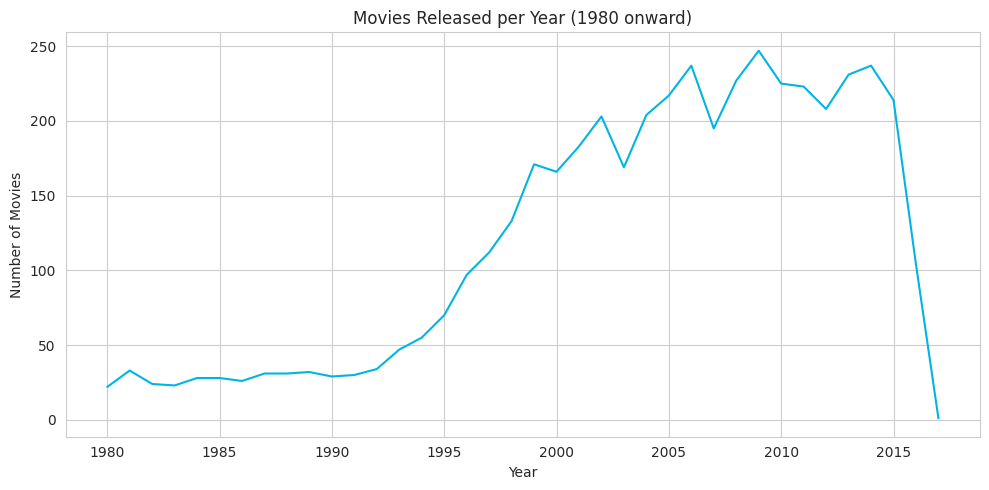

In [18]:
yearly = pd.to_datetime(df['release_date']).dt.year.value_counts().sort_index()
yearly = yearly[yearly.index >= 1980]
plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, color='#01b4e4')
plt.title('Movies Released per Year (1980 onward)')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('viz_movies_per_year.png', dpi=120)
plt.show()

## 11. Save the processed dataset

In [19]:
output_cols = ['id', 'title', 'genres_list', 'director', 'cast_list', 'keywords_list',
               'overview', 'popularity', 'vote_average', 'vote_count', 'weighted_rating',
               'release_date', 'runtime']
df[output_cols].to_csv('tmdb_movies_processed.csv', index=False)
print(f"Saved tmdb_movies_processed.csv with {df.shape[0]} movies")

Saved tmdb_movies_processed.csv with 4799 movies


## 12. Try it yourself

Change the title below to get hybrid recommendations for any movie in the dataset.

In [20]:
recommend('Titanic', top_n=10)

,title,vote_average,vote_count,similarity,hybrid_score
0,WALL·E,7.8,6296,0.123564,0.474139
1,The Notebook,7.7,3067,0.106165,0.420084
2,Captain Phillips,7.6,2454,0.139648,0.412865
3,Serenity,7.4,1264,0.101673,0.323525
4,Master and Commander: The Far Side of the World,6.9,790,0.126849,0.249957
5,Triangle,6.9,612,0.134338,0.243950
6,The Adventures of Tintin,6.7,2061,0.094864,0.232468
7,In the Heart of the Sea,6.5,1276,0.154137,0.228104
8,King Kong,6.6,2337,0.102391,0.223076
9,Pirates of the Caribbean: On Stranger Tides,6.4,4948,0.136297,0.216335
